# H-005 · Window screens (OLS / ADF / entry z / z)

Sequential screens for OLS lookback, ADF window, entry z and fixed z-window, under **frozen
`BREAK_STAR` (H-003) and `BOOK_STAR` (H-004)**. Formerly Part B of H-003.

**Why this runs after H-004.** Fitting these windows on the frozen book and then handing them to
both arms would tune them on one architecture and bias the H-004 bake-off toward `freeze`. The
rotating arm would be competing with windows optimised for its opponent.

Each stage freezes one STAR before the next; these are sequential screens, **not** a joint grid.
Day-unit grids, session-scaled on 1h by `lookbacks_for_bar`.

STARs frozen here: `OLS_WINDOW_STAR`, `ADF_WINDOW_STAR`, `ENTRY_Z_STAR`, `Z_WINDOW_STAR`.

If `BOOK_STAR = rotate`, the discovery lookback `L` (pre-registered at 252 for H-004) may be
screened here and nowhere earlier.

Metrics: fold-val Sharpe, max DD, corr to S1. Rank on net Sharpe and read correlation beside it —
**a negative correlation to S1 beats a low positive one**.


## 0. Imports & Config


In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from backtest.s2_coint.report import (
    fold_table,
    fold_val_metrics,
    load_star_stack,
    median_sharpe_hint,
    plot_fold_boxplots,
    require_star,
    save_star_stack,
    write_tearsheet_pdf,
)
from backtest.s2_coint.research import (
    ARTIFACTS_DIR,
    DAY_OLS_WINDOW,
    DAY_Z_WINDOW,
    DEFAULT_STAR_STACK,
    config_from_stack,
    is_end_for_stack,
    frozen_pairs_for_universe,
    load_s1_weekly,
    load_universe_panels,
    lookbacks_for_bar,
    overlay_ols_hedge,
    split_is_oos,
    tearsheet_path,
)
from backtest.s2_coint.runner import run_s2_backtest
from backtest.s2_coint.walkforward import embargo_bars_for_config, make_s2_folds

STAR_PATH = DEFAULT_STAR_STACK
TEARSHEET_DIR = ARTIFACTS_DIR
stack = load_star_stack(STAR_PATH)

# Universe comes from H-001. The book is the ranked frozen book (caps 6 / 2) written by
# H-001; PAIRS_STAR is only populated once BOOK_STAR = freeze in H-004.
require_star("UNIVERSE_STAR", stack.get("UNIVERSE_STAR"))
UNIVERSE = str(stack["UNIVERSE_STAR"])
PAIRS_STAR = list(stack.get("PAIRS_STAR") or frozen_pairs_for_universe(UNIVERSE, "1d", root=ROOT))

# Sequential day-unit grids; lookbacks_for_bar session-scales these on 1h.
OLS_DAY_GRID = (504, 252, 126, 63)  # 2y / 1y / 6m / quarterly
ADF_DAY_GRID = (504, 252, 126, 63)
ENTRY_Z_GRID = (1.5, 2.0, 2.5)
Z_DAY_GRID = (40, 60, 90)

print("stack keys:", sorted(stack))
print("UNIVERSE", UNIVERSE, "PAIRS", PAIRS_STAR)
print("n_variants sequential", len(OLS_DAY_GRID), "+", len(ADF_DAY_GRID), "+", len(ENTRY_Z_GRID), "+", len(Z_DAY_GRID))


stack keys: ['ADF_WINDOW_STAR', 'BAR_STAR', 'BOOK_STAR', 'BREAK_STAR', 'ENTRY_Z_STAR', 'HEDGE_STAR', 'KALMAN_DELTA_STAR', 'OLS_WINDOW_STAR', 'PAIRS_STAR', 'RESEARCH_IS_END_STAR', 'UNIVERSE_STAR', 'Z_WINDOW_STAR']
UNIVERSE D PAIRS ['WSO|WSO.B', 'HEI|HEI.A', 'NWS|NWSA']
n_variants sequential 4 + 4 + 3 + 3


## 1. Load frozen panel under `BREAK_STAR` / `BOOK_STAR`

Panel is rebuilt on default day windows so every screen starts from the same baseline.


**Book under `BOOK_STAR`.** `BOOK_STAR = freeze` scores the screens on the frozen ranked
book directly. `BOOK_STAR = rotate` scores them on the rotating book: load the quarterly
selections with `backtest.s2_coint.rotation.build_active_schedule` (or the saved
`s2_rebalance_{letter}_1d.csv`), turn them into entry masks with `schedule_to_masks`, and
score via `simulate_rotating_book` so demotion and orientation locks stay in force. The
window grids themselves are identical either way.


In [2]:
require_star("BAR_STAR", stack.get("BAR_STAR"))
require_star("BREAK_STAR", stack.get("BREAK_STAR"))
require_star("BOOK_STAR", stack.get("BOOK_STAR"))
BAR = str(stack["BAR_STAR"])
BOOK = str(stack["BOOK_STAR"])
train, full = load_universe_panels(UNIVERSE, BAR, PAIRS_STAR, root=ROOT)
lb0 = lookbacks_for_bar(BAR)
# Rebuild with default day windows so every screen starts from the same baseline.
train = overlay_ols_hedge(
    train,
    ols_window=lb0["ols_window"],
    z_window=lb0["z_window"],
    hl_window=lb0["hl_window"],
    adf_window=lb0["adf_window"],
)
full = overlay_ols_hedge(
    full,
    ols_window=lb0["ols_window"],
    z_window=lb0["z_window"],
    hl_window=lb0["hl_window"],
    adf_window=lb0["adf_window"],
)
is_end = is_end_for_stack(stack, full if BAR == "1h" else train)
if BAR == "1d":
    is_panel, oos_panel = train.copy(), full.loc[pd.to_datetime(full["date"]) > is_end].copy()
else:
    is_panel, oos_panel = split_is_oos(full, is_end=is_end)
s1_weekly = load_s1_weekly(ROOT)
print("bar", BAR, "is_end", is_end, "IS rows", len(is_panel), "OOS rows", len(oos_panel))
is_panel.head()


bar 1d is_end 2021-12-31 00:00:00 IS rows 16177 OOS rows 3492


,date,pair_id,ticker_y,ticker_x,open_y,high_y,low_y,close_y,open_x,high_x,low_x,close_x,alpha,beta,spread,z,half_life,adf_pvalue,variance_jump
0,1990-01-02,WSO|WSO.B,WSO,WSO.B,1.112374,1.112374,1.112374,1.112374,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1990-01-03,WSO|WSO.B,WSO,WSO.B,1.082310,1.082310,1.082310,1.082310,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1990-01-04,WSO|WSO.B,WSO,WSO.B,1.082310,1.082310,1.082310,1.082310,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1990-01-05,WSO|WSO.B,WSO,WSO.B,1.082310,1.082310,1.082310,1.082310,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1990-01-08,WSO|WSO.B,WSO,WSO.B,1.082310,1.082310,1.082310,1.082310,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Walk-forward folds


In [3]:
panel = is_panel.copy()
dates = pd.DatetimeIndex(pd.to_datetime(panel["date"])).sort_values().unique()
folds = make_s2_folds(dates, n_folds=3, embargo_bars=embargo_bars_for_config(bar=BAR))
fold_table(folds)


,fold_id,train_start,train_end,n_train,embargo_start,embargo_end,val_start,val_end,n_val
0,1,1990-01-02,1997-12-11,2011,1997-12-12,1997-12-18,1997-12-19,2005-12-23,2016
1,2,1990-01-02,2005-12-16,4027,2005-12-19,2005-12-23,2005-12-27,2013-12-30,2016
2,3,1990-01-02,2013-12-20,6043,2013-12-23,2013-12-30,2013-12-31,2021-12-31,2016


## 3. Sequential screens under frozen `BREAK_STAR`

Each stage freezes one STAR before the next. Boxplots of Sharpe / max DD / corr to S1;
cost commentary is manual from trade counts when useful.


### 3.1 OLS lookback screen → `OLS_WINDOW_STAR`


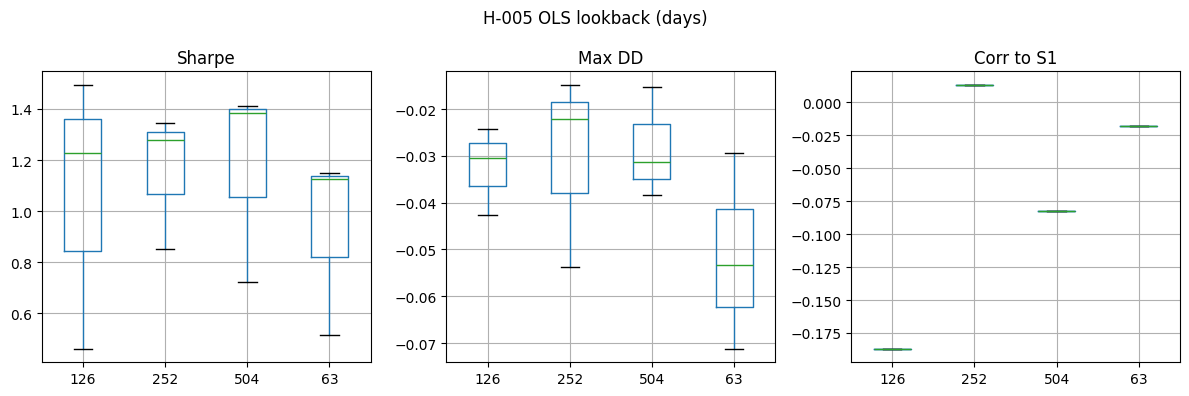

504


,ann_sharpe,max_drawdown,corr_to_s1
arm,,,
126,1.228875,-0.030384,-0.187197
252,1.279236,-0.022017,0.013406
504,1.386245,-0.031303,-0.082632
63,1.126065,-0.053423,-0.018203


In [4]:
require_star("BREAK_STAR", stack.get("BREAK_STAR"))
configs_ols = {}
panels_ols = {}
for days in OLS_DAY_GRID:
    lb = lookbacks_for_bar(BAR, ols_days=days, z_days=DAY_Z_WINDOW, adf_days=DAY_OLS_WINDOW)
    p = overlay_ols_hedge(
        panel,
        ols_window=lb["ols_window"],
        z_window=lb["z_window"],
        hl_window=lb["hl_window"],
        adf_window=lb["adf_window"],
    )
    panels_ols[days] = p
    configs_ols[str(days)] = config_from_stack(
        stack, ols_window=lb["ols_window"], z_window=lb["z_window"], adf_window=lb["adf_window"]
    )

# fold_val_metrics expects one panel; score each arm on its own overlay.
rows = []
for days, p in panels_ols.items():
    cfg = {str(days): configs_ols[str(days)]}
    part = fold_val_metrics(p, folds, cfg, s1_weekly=s1_weekly)
    rows.append(part)
fold_ols = pd.concat(rows, ignore_index=True)
plot_fold_boxplots(fold_ols, title="H-005 OLS lookback (days)")
plt.show()
print(median_sharpe_hint(fold_ols))
fold_ols.groupby("arm")[["ann_sharpe", "max_drawdown", "corr_to_s1"]].median()


In [5]:
OLS_WINDOW_STAR = 252   # TODO day units: 504 | 252 | 126 | 63
require_star("OLS_WINDOW_STAR", OLS_WINDOW_STAR)
stack["OLS_WINDOW_STAR"] = int(OLS_WINDOW_STAR)
save_star_stack(STAR_PATH, stack)
print("wrote OLS_WINDOW_STAR", OLS_WINDOW_STAR)


wrote OLS_WINDOW_STAR 252


### 3.2 ADF window screen → `ADF_WINDOW_STAR`


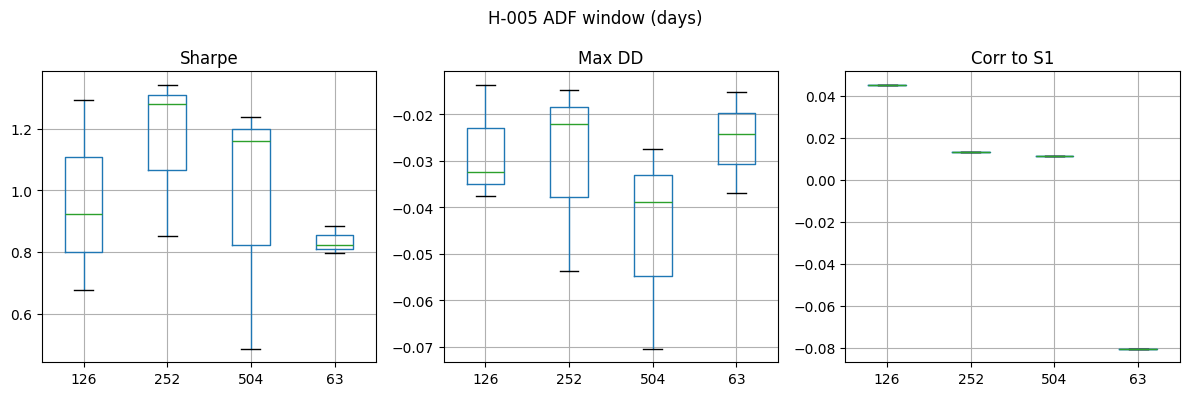

252


,ann_sharpe,max_drawdown,corr_to_s1
arm,,,
126,0.922227,-0.032385,0.045323
252,1.279236,-0.022017,0.013406
504,1.159893,-0.038883,0.011465
63,0.824026,-0.024319,-0.080651


In [6]:
require_star("OLS_WINDOW_STAR", stack.get("OLS_WINDOW_STAR"))
ols_days = int(stack["OLS_WINDOW_STAR"])
rows = []
for days in ADF_DAY_GRID:
    lb = lookbacks_for_bar(BAR, ols_days=ols_days, z_days=DAY_Z_WINDOW, adf_days=days)
    p = overlay_ols_hedge(
        panel,
        ols_window=lb["ols_window"],
        z_window=lb["z_window"],
        hl_window=lb["hl_window"],
        adf_window=lb["adf_window"],
    )
    cfg = {str(days): config_from_stack(
        stack, ols_window=lb["ols_window"], z_window=lb["z_window"], adf_window=lb["adf_window"]
    )}
    rows.append(fold_val_metrics(p, folds, cfg, s1_weekly=s1_weekly))
fold_adf = pd.concat(rows, ignore_index=True)
plot_fold_boxplots(fold_adf, title="H-005 ADF window (days)")
plt.show()
print(median_sharpe_hint(fold_adf))
fold_adf.groupby("arm")[["ann_sharpe", "max_drawdown", "corr_to_s1"]].median()


In [7]:
ADF_WINDOW_STAR = 252  # TODO day units: 504 | 252 | 126 | 63
require_star("ADF_WINDOW_STAR", ADF_WINDOW_STAR)
stack["ADF_WINDOW_STAR"] = int(ADF_WINDOW_STAR)
save_star_stack(STAR_PATH, stack)
print("wrote ADF_WINDOW_STAR", ADF_WINDOW_STAR)


wrote ADF_WINDOW_STAR 252


### 3.3 Entry z screen → `ENTRY_Z_STAR`


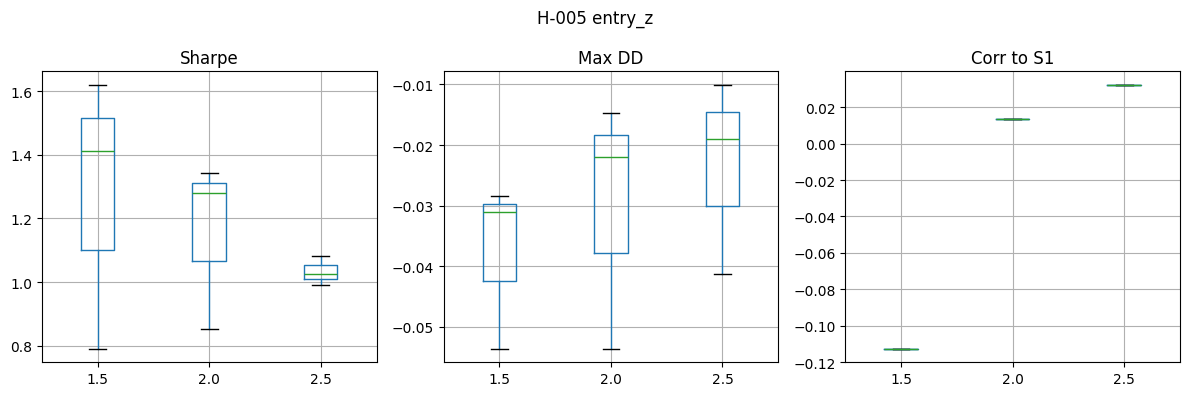

1.5


,ann_sharpe,max_drawdown,corr_to_s1
arm,,,
1.5,1.411883,-0.031050,-0.112859
2.0,1.279236,-0.022017,0.013406
2.5,1.025847,-0.018984,0.032506


In [8]:
require_star("ADF_WINDOW_STAR", stack.get("ADF_WINDOW_STAR"))
ols_days = int(stack["OLS_WINDOW_STAR"])
adf_days = int(stack["ADF_WINDOW_STAR"])
lb = lookbacks_for_bar(BAR, ols_days=ols_days, z_days=DAY_Z_WINDOW, adf_days=adf_days)
panel_entry = overlay_ols_hedge(
    panel,
    ols_window=lb["ols_window"],
    z_window=lb["z_window"],
    hl_window=lb["hl_window"],
    adf_window=lb["adf_window"],
)
configs_ez = {
    str(ez): config_from_stack(
        stack,
        entry_z=float(ez),
        ols_window=lb["ols_window"],
        z_window=lb["z_window"],
        adf_window=lb["adf_window"],
    )
    for ez in ENTRY_Z_GRID
}
fold_ez = fold_val_metrics(panel_entry, folds, configs_ez, s1_weekly=s1_weekly)
plot_fold_boxplots(fold_ez, title="H-005 entry_z")
plt.show()
print(median_sharpe_hint(fold_ez))
fold_ez.groupby("arm")[["ann_sharpe", "max_drawdown", "corr_to_s1"]].median()


In [9]:
ENTRY_Z_STAR = 1.5  # TODO: 1.5 | 2.0 | 2.5
require_star("ENTRY_Z_STAR", ENTRY_Z_STAR)
stack["ENTRY_Z_STAR"] = float(ENTRY_Z_STAR)
save_star_stack(STAR_PATH, stack)
print("wrote ENTRY_Z_STAR", ENTRY_Z_STAR)


wrote ENTRY_Z_STAR 1.5


### 3.4 Z-window screen → `Z_WINDOW_STAR`


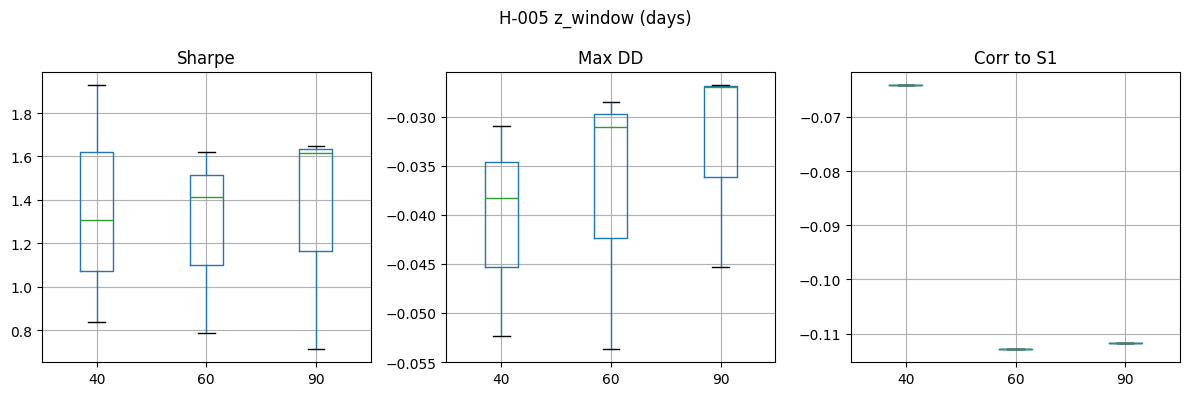

90


,ann_sharpe,max_drawdown,corr_to_s1
arm,,,
40,1.307565,-0.038266,-0.064081
60,1.411883,-0.031050,-0.112859
90,1.617463,-0.026987,-0.111699


In [10]:
require_star("ENTRY_Z_STAR", stack.get("ENTRY_Z_STAR"))
ols_days = int(stack["OLS_WINDOW_STAR"])
adf_days = int(stack["ADF_WINDOW_STAR"])
rows = []
for days in Z_DAY_GRID:
    lb = lookbacks_for_bar(BAR, ols_days=ols_days, z_days=days, adf_days=adf_days)
    p = overlay_ols_hedge(
        panel,
        ols_window=lb["ols_window"],
        z_window=lb["z_window"],
        hl_window=lb["hl_window"],
        adf_window=lb["adf_window"],
    )
    cfg = {str(days): config_from_stack(
        stack,
        ols_window=lb["ols_window"],
        z_window=lb["z_window"],
        adf_window=lb["adf_window"],
    )}
    rows.append(fold_val_metrics(p, folds, cfg, s1_weekly=s1_weekly))
fold_z = pd.concat(rows, ignore_index=True)
plot_fold_boxplots(fold_z, title="H-005 z_window (days)")
plt.show()
print(median_sharpe_hint(fold_z))
fold_z.groupby("arm")[["ann_sharpe", "max_drawdown", "corr_to_s1"]].median()


In [11]:
Z_WINDOW_STAR = 90  # TODO day units: 40 | 60 | 90
require_star("Z_WINDOW_STAR", Z_WINDOW_STAR)
stack["Z_WINDOW_STAR"] = int(Z_WINDOW_STAR)
save_star_stack(STAR_PATH, stack)
print("wrote Z_WINDOW_STAR", Z_WINDOW_STAR)


wrote Z_WINDOW_STAR 90


## 4. Sealed OOS once (full frozen stack)


In [12]:
stack = load_star_stack(STAR_PATH)
for key in ("BREAK_STAR", "OLS_WINDOW_STAR", "ADF_WINDOW_STAR", "ENTRY_Z_STAR", "Z_WINDOW_STAR"):
    require_star(key, stack.get(key))
lb = lookbacks_for_bar(
    BAR,
    ols_days=int(stack["OLS_WINDOW_STAR"]),
    z_days=int(stack["Z_WINDOW_STAR"]),
    adf_days=int(stack["ADF_WINDOW_STAR"]),
)
oos_feat = overlay_ols_hedge(
    oos_panel,
    ols_window=lb["ols_window"],
    z_window=lb["z_window"],
    hl_window=lb["hl_window"],
    adf_window=lb["adf_window"],
)
oos_cfg = config_from_stack(stack)
oos = run_s2_backtest(oos_feat, oos_cfg, s1_weekly=s1_weekly)
print(oos.metrics)
arm = f"{stack['BREAK_STAR']}_ols{stack['OLS_WINDOW_STAR']}_adf{stack['ADF_WINDOW_STAR']}_ez{stack['ENTRY_Z_STAR']}_z{stack['Z_WINDOW_STAR']}"
write_tearsheet_pdf(tearsheet_path("H-003", arm), oos.returns, title=f"H-003 sealed OOS {arm}")
print("tearsheet", tearsheet_path("H-003", arm))


{'ann_sharpe': 1.3782836463624295, 'max_drawdown': -0.0231460849862819, 'n_days': 1162, 'corr_to_s1': -0.02571893994409521}
tearsheet C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\04_backtest\s2_coint\artifacts\H-003_block_05_flat_10_ols252_adf252_ez1.5_z90.pdf


## 5. Notes for next hyp


H-006 Kalman β vs static OLS hedge is next, under frozen `BREAK_STAR`, `BOOK_STAR` and the
window STARs frozen here. Do not reopen these grids on sealed OOS.
